In [1]:
from schelling import SchellingModel
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


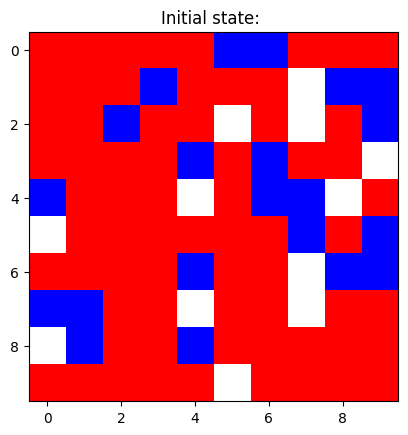

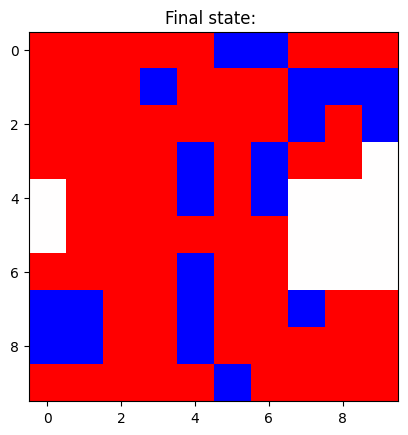

In [5]:
model = SchellingModel(10,10,0.8,0.2,0.3)
initial_grid_data = model.get_grid_status()
plt.imshow(initial_grid_data,cmap='bwr')
plt.title("Initial state: ")
plt.show()

for i in range(50):
    model.step()

final_grid_data = model.get_grid_status()
plt.imshow(final_grid_data,cmap='bwr')
plt.title("Final state: ")
plt.show()



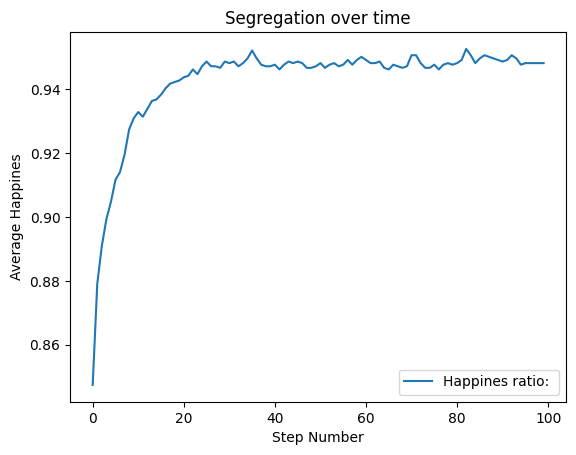

In [22]:
model_stats = SchellingModel(50,50,0.8,0.2,0.3)

for i in range(100):
    model_stats.step()

data = model_stats.datacollector.get_model_vars_dataframe()
data.plot()
plt.title("Segregation over time")
plt.ylabel("Average Happines")
plt.xlabel("Step Number")
plt.show()




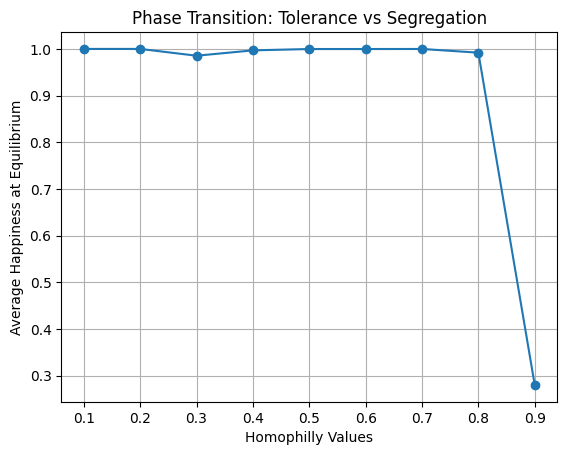

In [4]:
homophily_values= np.arange(0.1,1.0,0.1)
results =[]

for h in homophily_values:
    batch_scores=[]

    for run in range(10):
        model = SchellingModel(50,50,0.8,0.2,h)

        for step in range(100):
            model.step()

        final_happiness = model.datacollector.get_model_vars_dataframe().iloc[-1]["Happiness Ratio: "]
        batch_scores.append(final_happiness)

    avg_score = np.mean(batch_scores)
    results.append({"Homophily": h, "Final Happiness": avg_score})
    

df_results = pd.DataFrame(results)

plt.figure()
plt.plot(df_results["Homophily"], df_results["Final Happiness"], marker = 'o')
plt.title("Phase Transition: Tolerance vs Segregation")
plt.xlabel("Homophilly Values")
plt.ylabel("Average Happiness at Equilibrium")
plt.grid(True)
plt.show()
    


